# Practical 02 — Covariance and Correlation

## 1. Aim & Objectives

**Aim:** To compute the covariance and the Pearson correlation between the features of a dataset.

**Objectives:**
1. Load the Iris dataset and separate its numeric feature columns.
2. Compute the covariance matrix and the correlation matrix using Pandas.
3. Display both matrices as Matplotlib heatmaps and compare them.

## 2. Complete Python Code


Shape of dataset : (150, 5)
   sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm species
0              5.1             3.5              1.4             0.2  setosa
1              4.9             3.0              1.4             0.2  setosa
2              4.7             3.2              1.3             0.2  setosa
3              4.6             3.1              1.5             0.2  setosa
4              5.0             3.6              1.4             0.2  setosa

Covariance matrix:
                 sepal_length_cm  sepal_width_cm  petal_length_cm  \
sepal_length_cm            0.686          -0.042            1.274   
sepal_width_cm            -0.042           0.190           -0.330   
petal_length_cm            1.274          -0.330            3.116   
petal_width_cm             0.516          -0.122            1.296   

                 petal_width_cm  
sepal_length_cm           0.516  
sepal_width_cm           -0.122  
petal_length_cm           1.296  
petal_width_cm

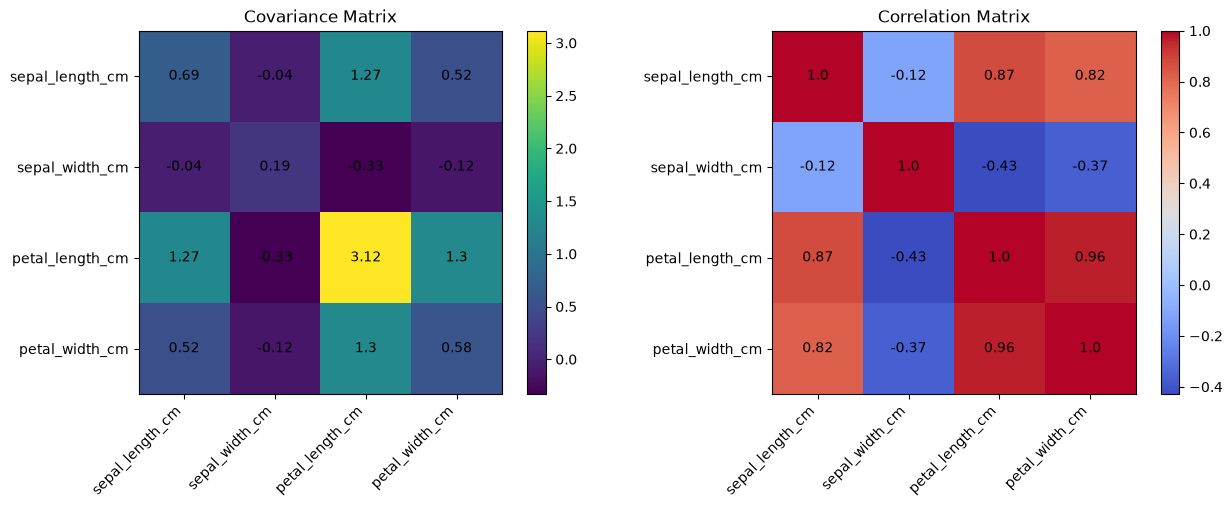

In [1]:
# Practical 02 - Covariance and Correlation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the dataset
CSV = "data/iris.csv"
URL = "https://raw.githubusercontent.com/liamdev07/machine-learning-laboratory/main/02_Covariance_Correlation/data/iris.csv"
path = CSV if os.path.exists(CSV) else URL
df = pd.read_csv(path)

print("Shape of dataset :", df.shape)
print(df.head())

# Step 2: Keep only the numeric feature columns
features = df.drop(columns="species")

# Step 3: Covariance and correlation
cov_matrix = features.cov()
corr_matrix = features.corr()

print("\nCovariance matrix:")
print(cov_matrix.round(3))
print("\nCorrelation matrix (Pearson):")
print(corr_matrix.round(3))

# Step 4: Plot both matrices as heatmaps
labels = list(features.columns)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for axis, matrix, title, cmap in [
    (ax[0], cov_matrix, "Covariance Matrix", "viridis"),
    (ax[1], corr_matrix, "Correlation Matrix", "coolwarm"),
]:
    image = axis.imshow(matrix, cmap=cmap)
    axis.set_xticks(range(len(labels)))
    axis.set_yticks(range(len(labels)))
    axis.set_xticklabels(labels, rotation=45, ha="right")
    axis.set_yticklabels(labels)
    axis.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            axis.text(j, i, round(matrix.iloc[i, j], 2), ha="center", va="center", color="black")
    fig.colorbar(image, ax=axis)

plt.tight_layout()
plt.show()


## 3. Line-by-Line Code Explanation

- `import numpy as np` / `import pandas as pd` — NumPy for numbers, Pandas for the data table.
- `import matplotlib.pyplot as plt` — used to draw the two heatmaps.
- `path = CSV if os.path.exists(CSV) else URL` — read the local file, or download it on Colab.
- `df = pd.read_csv(path)` — loads the Iris dataset (4 measurements + the flower `species`).
- `df.drop(columns="species")` — removes the text column, because covariance needs numbers only. The result is stored in `features`.
- `features.cov()` — covariance matrix. Each cell says whether two features increase together (positive) or move opposite (negative). Its value depends on the units of measurement.
- `features.corr()` — Pearson correlation matrix. This is covariance divided by the two standard deviations, so every value lies between −1 and +1 and has no unit.
- `.round(3)` — shows only 3 digits after the decimal point so the table is readable.
- `labels = list(features.columns)` — the four feature names, used to label the heatmap axes.
- `plt.subplots(1, 2, figsize=(13, 5))` — one figure holding two heatmaps side by side.
- `axis.imshow(matrix, cmap=...)` — draws the matrix as coloured squares; the colour shows the value.
- `set_xticks` / `set_xticklabels` — put the feature names on the axes instead of 0, 1, 2, 3.
- The double `for i ... for j` loop with `axis.text(...)` — writes the actual number inside every square.
- `fig.colorbar(image, ax=axis)` — adds the colour scale bar next to each heatmap.
- `plt.show()` — displays the figure.


## 4. Output & Graph Interpretation

Petal length and petal width show a very high positive correlation (about +0.96), so these two features carry almost the same information.

Sepal width is slightly negatively correlated with the petal features, and the covariance heatmap looks different from the correlation heatmap only because covariance still depends on the measurement units.
